# Import Library and Dataset

In [57]:
# pip install emoji


In [58]:
# Import essential library
import pandas as pd
import numpy as np
import re, html, emoji
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay

In [59]:
# Import datasets
general_df = pd.read_csv("goemotions_mrm8488_train.csv")
domain_df = pd.read_csv("stockemotions_full.csv", skiprows = 1)

print(general_df.shape)
print(domain_df.shape)
print(general_df.head(10))
print(domain_df.head(10))

(211225, 37)
(10000, 7)
                                                text       id  \
0                                    That game hurt.  eew5j0j   
1   >sexuality shouldn’t be a grouping category I...  eemcysk   
2     You do right, if you don't care then fuck 'em!  ed2mah1   
3                                 Man I love reddit.  eeibobj   
4  [NAME] was nowhere near them, he was by the Fa...  eda6yn6   
5  Right? Considering it’s such an important docu...  eespn2i   
6  He isn't as big, but he's still quite popular....  eczuekb   
7  That's crazy; I went to a super [RELIGION] hig...  ed5tx8y   
8                                that's adorable asf  ef961hv   
9  "Sponge Blurb Pubs Quaw Haha GURR ha AAa!" fin...  edl7cr3   

                author             subreddit    link_id   parent_id  \
0                Brdd9                   nrl  t3_ajis4z  t1_eew18eq   
1          TheGreen888      unpopularopinion  t3_ai4q37   t3_ai4q37   
2             Labalool           confessions  t

# Basic Statistics


In [60]:
# The shape of the datasets
print(f'General Dataset: {general_df.shape}')
print(f'Domain Dataset: {domain_df.shape}')

General Dataset: (211225, 37)
Domain Dataset: (10000, 7)


In [61]:
# Check datatype
print(general_df.info())
print("________________________________\n")
print(domain_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211225 entries, 0 to 211224
Data columns (total 37 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   text                  211225 non-null  object 
 1   id                    211225 non-null  object 
 2   author                211225 non-null  object 
 3   subreddit             211225 non-null  object 
 4   link_id               211225 non-null  object 
 5   parent_id             211225 non-null  object 
 6   created_utc           211225 non-null  float64
 7   rater_id              211225 non-null  int64  
 8   example_very_unclear  211225 non-null  bool   
 9   admiration            211225 non-null  int64  
 10  amusement             211225 non-null  int64  
 11  anger                 211225 non-null  int64  
 12  annoyance             211225 non-null  int64  
 13  approval              211225 non-null  int64  
 14  caring                211225 non-null  int64  
 15  

In [62]:
# Checking missing value
print(f'General Dataset: {general_df.isnull().sum()}')
print("________________________________\n")
print(f'Domain Dataset: {domain_df.isnull().sum()}')

General Dataset: text                    0
id                      0
author                  0
subreddit               0
link_id                 0
parent_id               0
created_utc             0
rater_id                0
example_very_unclear    0
admiration              0
amusement               0
anger                   0
annoyance               0
approval                0
caring                  0
confusion               0
curiosity               0
desire                  0
disappointment          0
disapproval             0
disgust                 0
embarrassment           0
excitement              0
fear                    0
gratitude               0
grief                   0
joy                     0
love                    0
nervousness             0
optimism                0
pride                   0
realization             0
relief                  0
remorse                 0
sadness                 0
surprise                0
neutral                 0
dtype: int64
________

# Clean Dataset



In [63]:

# Fiter ()"example_very_unclear" = True) as it do not have any label
general_df = general_df[~general_df["example_very_unclear"]]
print(general_df["example_very_unclear"].head(10))

0     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
Name: example_very_unclear, dtype: bool


In [64]:
# Applying rarest-label strategy to balance the dataset
min_vote = 2
emotion_cols = general_df.columns[9:].tolist()
agg = general_df.groupby('text')[emotion_cols].sum()
mask = agg >= min_vote
agg = agg[mask.any(axis = 1)]
mask = mask[mask.any(axis = 1)]
rare_rank = mask.sum().rank(method = "first")
scores = (mask * rare_rank).where(mask)
agg["label"] = scores.idxmin(axis=1)
general_clean = agg.reset_index()[["text", "label"]]
print(general_clean.head(10))
print(general_clean.shape)


                                                text        label
0   "If you don't wear BROWN AND ORANGE...YOU DON...    annoyance
1   "What do Scottish people look like?" How I wo...         love
2     ### A surprise, to be sure, but a welcome one      surprise
3   '*Pray*, v. To ask that the laws of the unive...      neutral
4   >it'll get invaded by tankie, unfortunately. ...      neutral
5   And not all children's hospitals need the sam...     approval
6                Best number! [NAME], [NAME], [NAME]   admiration
7   Calm down and relax are the worst things to s...    annoyance
8   Change is hard. Find comfort in victory, even...      neutral
9   Don't be so stupid. Terrorism is inherently p...  disapproval
(53994, 2)


In [65]:
duplicate_value = general_clean[general_clean.duplicated("text", keep=False)].sort_values("text")
print("Duplicate Rows:", len(duplicate_value), "| Duplicate Text", duplicate_value["text"].nunique())

Duplicate Rows: 0 | Duplicate Text 0


In [66]:
#Check duplicate value
duplicate_data = domain_df[domain_df.duplicated()]
print(duplicate_data)

Empty DataFrame
Columns: [id, date, ticker, emo_label, senti_label, original, processed]
Index: []


In [67]:
def normalize_text(s):
    s = html.unescape(str(s))
    s = emoji.demojize(s, delimiters=(" [", "] "))
    s = re.sub(r"\[([a-z0-9_+\-]+)\]", lambda m: "[" + m.group(1).replace("_", " ").replace("-", " ") + "]", s)
    s = s.replace("\u200d", "").replace("\ufe0f", "")
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"@\w+", " ", s)
    s = re.sub(r"^\s*&?gt;+\s*|^\s*>+\s*", " ", s)
    s = re.sub(r"\$(?=[A-Za-z])", "", s)
    s = re.sub(r"[\U0001F000-\U0001FAFF\U0001F1E6-\U0001F1FF"r"\u2190-\u21FF\u2600-\u27BF\u2B00-\u2BFF]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

In [68]:
# GoEmotions
general_clean["text"] = general_clean["text"].map(normalize_text)
general_clean = general_clean.drop_duplicates("text").reset_index(drop=True)

# StockEmotions
domain_df["text"] = domain_df["processed"].map(normalize_text)
domain_df = domain_df.drop(columns = ['original','processed'])

print("general_clean:", general_clean.shape, "| duplicate:", general_clean["text"].duplicated().sum())
print("domain_clean :", domain_df.shape, "| duplicate:", domain_df["text"].duplicated().sum())

general_clean.to_csv("general_clean.csv", index=False, encoding="utf-8")
domain_df.to_csv("domain_clean.csv", index=False, encoding="utf-8")

general_clean: (53992, 2) | duplicate: 0
domain_clean : (10000, 6) | duplicate: 0


# Feature Engineering

In [69]:
seed = 42

label_map = {
    "realization": "ambiguous",
    "amusement": "amusement",
    "anger": "anger", "annoyance": "anger", "disapproval": "anger",
    "nervousness": "anxiety",
    "admiration": "belief", "approval": "belief","caring": "belief",
    "pride":"belief","gratitude": "belief","love": "belief",
    "confusion": "confusion",  "curiosity": "confusion",
    "sadness": "depression", "grief": "depression", "remorse": "depression","disappointment": "depression", "embarrassment": "depression",
    "disgust": "disgust",
    "excitement": "excitement", "joy": "excitement",
    "optimism": "optimism", "relief": "optimism", "desire": "optimism",
    "fear": "panic",
    "surprise": "surprise",
}

general = pd.read_csv("general_clean.csv")
domain  = pd.read_csv("domain_clean.csv").rename(columns={"emo_label": "label"})

general["label"] = general["label"].map(label_map)
general = general.dropna(subset=["label"]).reset_index(drop=True)

print(f"general: {len(general)} rows | domain: {len(domain)} rows | {general['label'].nunique()} lop")


general: 38042 rows | domain: 10000 rows | 12 lop


In [70]:
general_train, general_test = train_test_split(general, test_size=.2, stratify=general["label"], random_state=seed)
domain_train, domain_test = train_test_split(domain, test_size=.2, stratify=domain["label"], random_state=seed)
 
print(f"general_train = {len(general_train)} general_test = {len(general_test)} | domain_train = {len(domain_train)} domain_test = {len(domain_test)}")

general_train = 30433 general_test = 7609 | domain_train = 8000 domain_test = 2000


# Machine Learning 

In [71]:
def validate_model_kfold(model, param_dist, X_train, y_train, name="", n_splits=5, n_iter=10):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
 
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=skf,
        scoring="f1_macro", 
        n_jobs=-1,
        verbose=1,
        random_state=seed,
    )
    search.fit(X_train, y_train)
 
    best_index = search.best_index_
    fold_scores = [search.cv_results_[f"split{k}_test_score"][best_index] for k in range(n_splits)]
    mean_f1 = np.mean(fold_scores)
 
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar([f"Fold {i+1}" for i in range(n_splits)], fold_scores, color="steelblue", edgecolor="white", width=0.5)
    ax.axhline(mean_f1, color="tomato", linestyle="--", linewidth=1.5, label=f"Mean macro-F1: {mean_f1:.2%}")
    for bar, score in zip(bars, fold_scores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f"{score:.2%}", ha="center", va="bottom", fontsize=10)
    ax.set_title(f"Macro-F1 per Fold — {name}")
    ax.set_xlabel("Fold"); ax.set_ylabel("Macro-F1"); ax.set_ylim(0, 1.1)
    ax.legend(); ax.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout(); plt.show()
 
    print(f"Best hyperparameters: {search.best_params_}")
    print(f"CV macro-F1: {search.best_score_:.2%}")
    return search.best_estimator_, search.best_params_

In [72]:
def vectorize_text(train_texts, test_texts, max_features=20000, ngram_range=(1, 2), min_df=2):
    vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range, min_df=min_df)
    X_train = vectorizer.fit_transform(train_texts)
    X_test = vectorizer.transform(test_texts)
    return X_train, X_test, vectorizer

In [73]:
# TRY MANY COMBINATIONS AS YOU NEED
param_dist_lr = {
    "C": [0.1, 1, 10],
    "class_weight": ["balanced"],}
 
param_dist_svc = {
    "C": [0.1, 1],
    "class_weight": ["balanced"],}
 
param_dist_nb = {
    "alpha": [0.1, 0.5, 1.0],}

In [74]:
trainsets = {
    "A: General only": general_train,
    "B: Domain only": domain_train,
    "C: General + Domain": pd.concat([general_train, domain_train], ignore_index=True)}

In [75]:
X_A_train, X_A_test, vec_A = vectorize_text(general_train["text"], domain_test["text"])
y_A_train = general_train["label"]

X_B_train, X_B_test, vec_B = vectorize_text(domain_train["text"], domain_test["text"])
y_B_train = domain_train["label"]

train_C = pd.concat([general_train[["text","label"]], domain_train[["text","label"]]], ignore_index=True)
X_C_train, X_C_test, vec_C = vectorize_text(train_C["text"], domain_test["text"])
y_C_train = train_C["label"]

y_test = domain_test["label"]

print("A:", X_A_train.shape, "| B:", X_B_train.shape, "| C:", X_C_train.shape)

A: (30433, 20000) | B: (8000, 17752) | C: (38433, 20000)


In [76]:
def evaluate(model, X_test, name):
    pred = model.predict(X_test)
    f1  = f1_score(y_test, pred, average="macro", zero_division=0)
    acc = (pred == y_test).mean()
    print(f"\n{name} | TEST macro-F1 = {f1:.4f} | accuracy = {acc:.4f}\n")
    print(classification_report(y_test, pred, zero_division=0))
    return pred

Fitting 5 folds for each of 3 candidates, totalling 15 fits


/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=6. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


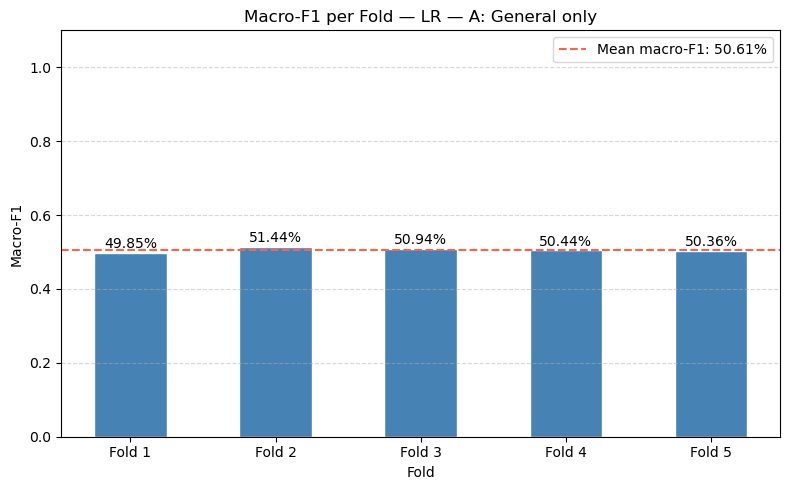

Best hyperparameters: {'class_weight': 'balanced', 'C': 1}
CV macro-F1: 50.61%

LR — A: General only | TEST macro-F1 = 0.1378 | accuracy = 0.1435

              precision    recall  f1-score   support

   ambiguous       0.11      0.26      0.16       174
   amusement       0.13      0.16      0.14       164
       anger       0.05      0.18      0.08        77
     anxiety       0.25      0.01      0.03       273
      belief       0.12      0.15      0.14       181
   confusion       0.23      0.30      0.26       122
  depression       0.07      0.20      0.10        41
     disgust       0.27      0.05      0.09       256
  excitement       0.22      0.16      0.18       277
    optimism       0.21      0.16      0.18       325
       panic       0.19      0.08      0.11        61
    surprise       0.16      0.24      0.19        49

    accuracy                           0.14      2000
   macro avg       0.17      0.16      0.14      2000
weighted avg       0.19      0.14      0.

In [ ]:
# Test - Model A
lr_A, best_lr_A = validate_model_kfold(
    LogisticRegression(random_state=seed, max_iter=1000),
    param_dist_lr, X_A_train, y_A_train, name="LR — A: General only", n_iter=6)

pred_lr_A = evaluate(lr_A, X_A_test, "LR — A: General only")